# Task 7 - Marker-Based Watershed

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

In [2]:
bgr = cv2.imread("coins(1).png")

if bgr is None:
    raise FileNotFoundError(
        "Place the touching-coins image as coins(1).png in the notebook folder."
    )

# Convert the image from BGR to RGB for displaying with Matplotlib
rgb = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2RGB
)

# Convert the image to grayscale for image processing
gray = cv2.cvtColor(
    bgr,
    cv2.COLOR_BGR2GRAY
)


In [5]:
# Apply Gaussian blur to reduce noise
blur = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

# Create a binary image using Otsu's thresholding
# Binary inversion makes the coins the foreground
_, th = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Create a 3x3 kernel for morphological operations
kernel = np.ones(
    (3, 3),
    np.uint8
)

# Remove small noise using morphological opening
opening = cv2.morphologyEx(
    th,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Dilate the opening result to obtain the sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

# Calculate the distance transform
# This gives the distance of each foreground pixel from the background
dist = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Threshold the distance transform to obtain the sure foreground
_, sure_fg = cv2.threshold(
    dist,
    0.5 * dist.max(),
    255,
    0
)

# Convert the sure foreground mask to 8-bit format
sure_fg = np.uint8(sure_fg)

# Find the unknown region between the sure foreground and background
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# Label the connected components of the sure foreground
n, markers = cv2.connectedComponents(sure_fg)

# Add 1 so that the background is labeled as 1 instead of 0
markers = markers + 1

# Mark the unknown region with 0
markers[unknown == 255] = 0

# Apply the Watershed algorithm
markers = cv2.watershed(
    bgr,
    markers
)

# Create a copy of the RGB image for visualization
final = rgb.copy()

# Mark watershed boundaries in red
#final[markers == -1] = [255, 0, 0] includes boundyry of image as well

# Get watershed boundaries
boundary = (markers == -1)

# Remove only the unwanted outer-image border
boundary[0, :] = False
boundary[-1, :] = False
boundary[:, 0] = False
boundary[:, -1] = False

# Keep watershed boundaries between coins red
final[boundary] = [255, 0, 0]


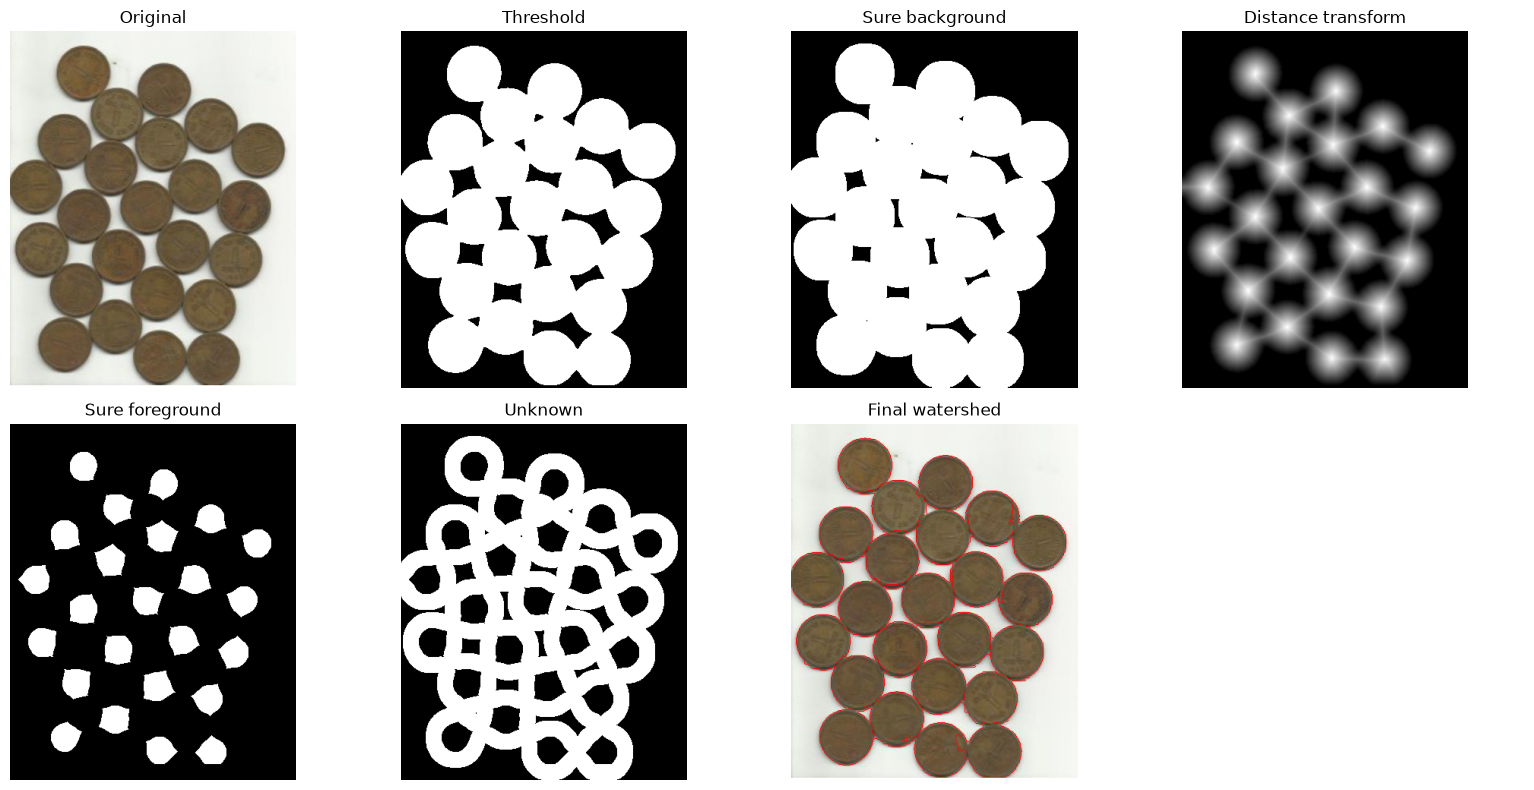

True

In [6]:
# Create a 2x4 grid to display the Watershed processing steps
fig, ax = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

# Prepare the images and their corresponding titles
items = [
    ("Original", rgb),
    ("Threshold", th),
    ("Sure background", sure_bg),
    ("Distance transform", dist),
    ("Sure foreground", sure_fg),
    ("Unknown", unknown),
    ("Final watershed", final)
]

# Display each processing step
for a, (title, image) in zip(
    ax.ravel(),
    items
):
    a.imshow(
        image,
        cmap="gray" if image.ndim == 2 else None
    )
    a.set_title(title)
    a.axis("off")

# Hide the unused subplot
ax.ravel()[-1].axis("off")

# Adjust spacing and display the results
plt.tight_layout()
plt.show()


# Save the final watershed result
# Convert RGB back to BGR before saving with OpenCV
cv2.imwrite(
    str(OUT / "task7_final.png"),
    cv2.cvtColor(
        final,
        cv2.COLOR_RGB2BGR
    )
)


## Inspection
The pipeline follows preprocessing, Otsu thresholding, morphological noise removal, sure background, distance transform, sure foreground, unknown region, connected-component marker labeling, watershed, and boundary visualization. Red boundaries indicate watershed lines. Visually compare those lines with the touching coin boundaries to judge separation.